In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [16]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()

        batch_size = batch_x.size(0)
        epoch_loss += loss.item() * batch_size
        correct = (logits.argmax(dim=1) == batch_y).sum().item()
        epoch_correct += correct
        epoch_samples += batch_size

    avg_loss = epoch_loss / epoch_samples
    avg_acc = epoch_correct / epoch_samples

    return avg_loss, avg_acc

In [17]:
def evaluate(model, val_loader, loss_fn, device):
    model.eval()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = loss_fn(logits, batch_y)

            batch_size = batch_x.size(0)
            epoch_loss += loss.item() * batch_size
            correct = (logits.argmax(dim=1) == batch_y).sum().item()
            epoch_correct += correct
            epoch_samples += batch_size

    avg_loss = epoch_loss / epoch_samples
    avg_acc = epoch_correct / epoch_samples

    return avg_loss, avg_acc

In [18]:
def fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch:03d}/{epochs:03d}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f}"
        )

    return history


In [ ]:
torch.manual_seed(42)

# 입력 20차원, 3개 클래스 분류 문제를 가짜로 생성
num_features = 20
num_classes = 3

X_train = torch.randn(600, num_features)
y_train = torch.randint(0, num_classes, (600,), dtype=torch.long)
X_val = torch.randn(200, num_features)
y_val = torch.randint(0, num_classes, (200,), dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Linear(num_features, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=20)


Epoch [001/010] train_loss=1.1209 train_acc=0.3117 val_loss=1.1049 val_acc=0.3350
Epoch [002/010] train_loss=1.0961 train_acc=0.3583 val_loss=1.1102 val_acc=0.3400
Epoch [003/010] train_loss=1.0843 train_acc=0.4050 val_loss=1.1090 val_acc=0.3400
Epoch [004/010] train_loss=1.0755 train_acc=0.4217 val_loss=1.1127 val_acc=0.3600
Epoch [005/010] train_loss=1.0681 train_acc=0.4350 val_loss=1.1145 val_acc=0.3500
Epoch [006/010] train_loss=1.0612 train_acc=0.4500 val_loss=1.1157 val_acc=0.3500
Epoch [007/010] train_loss=1.0538 train_acc=0.4650 val_loss=1.1189 val_acc=0.3450
Epoch [008/010] train_loss=1.0480 train_acc=0.4717 val_loss=1.1202 val_acc=0.3650
Epoch [009/010] train_loss=1.0413 train_acc=0.4933 val_loss=1.1234 val_acc=0.3700
Epoch [010/010] train_loss=1.0342 train_acc=0.4983 val_loss=1.1281 val_acc=0.3450


In [22]:
import matplotlib.pyplot as plt

def plot_loss(history):
    """
    train loss와 validation loss를 한 그래프에 표시합니다.
    """

    # epoch 번호를 1부터 시작하도록 만듭니다.
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))

    # train loss 곡선입니다.
    plt.plot(epochs, history["train_loss"], label="train_loss")

    # validation loss 곡선입니다.
    plt.plot(epochs, history["val_loss"], label="val_loss")

    # 그래프 제목과 축 이름을 지정합니다.
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    # 범례를 표시합니다.
    plt.legend()

    # 격자를 표시하면 변화 흐름을 읽기 쉽습니다.
    plt.grid(True)

    plt.show()

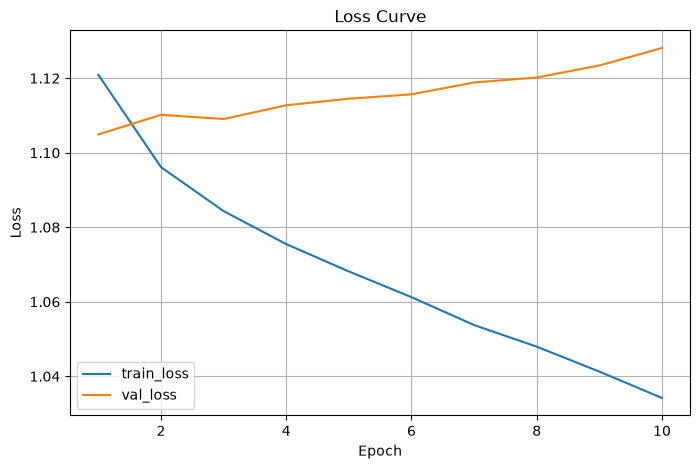

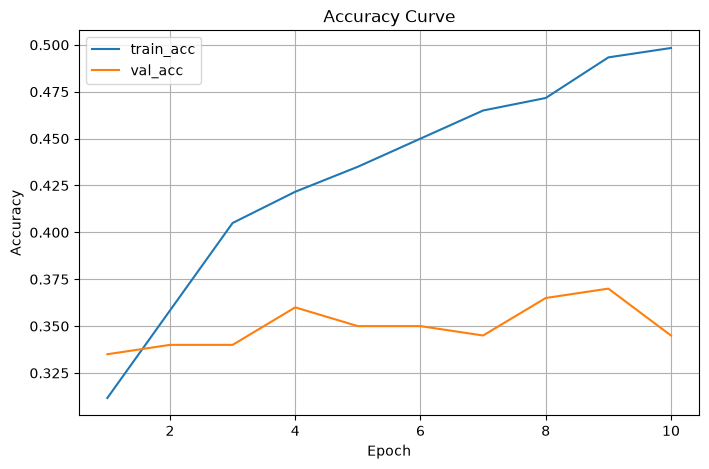

In [23]:
def plot_accuracy(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")

    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# 두 함수를 정의한 뒤 실제로 호출해야 그래프가 표시됩니다.
plot_loss(history)
plot_accuracy(history)